In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline



import math

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import warnings
warnings.filterwarnings("ignore")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
df = pd.read_csv("personality_datasert.csv")

## Dataset Features
* Time_spent_Alone: Hours spent alone daily (0–11).
* Stage_fear: Presence of stage fright (Yes/No).
* Social_event_attendance: Frequency of social events (0–10).
* Going_outside: Frequency of going outside (0–7).
* Drained_after_socializing: Feeling drained after socializing (Yes/No).
* Friends_circle_size: Number of close friends (0–15).
* Post_frequency: Social media post frequency (0–10).
* Personality: Target variable (Extrovert/Introvert).


In [2]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [3]:
df.shape

(2900, 8)

In [4]:
df.isnull().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   object 
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   object 
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [6]:
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.441180,2.872608,2.221597,4.232340,2.893587
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.963354,3.000000,5.000000,3.000000
75%,7.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [7]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.drop(columns=["Personality"]).select_dtypes(include='object').columns.tolist()
target_col = "Personality"

In [8]:
print(numeric_cols)
print(categorical_cols)
print(target_col)

['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
['Stage_fear', 'Drained_after_socializing']
Personality


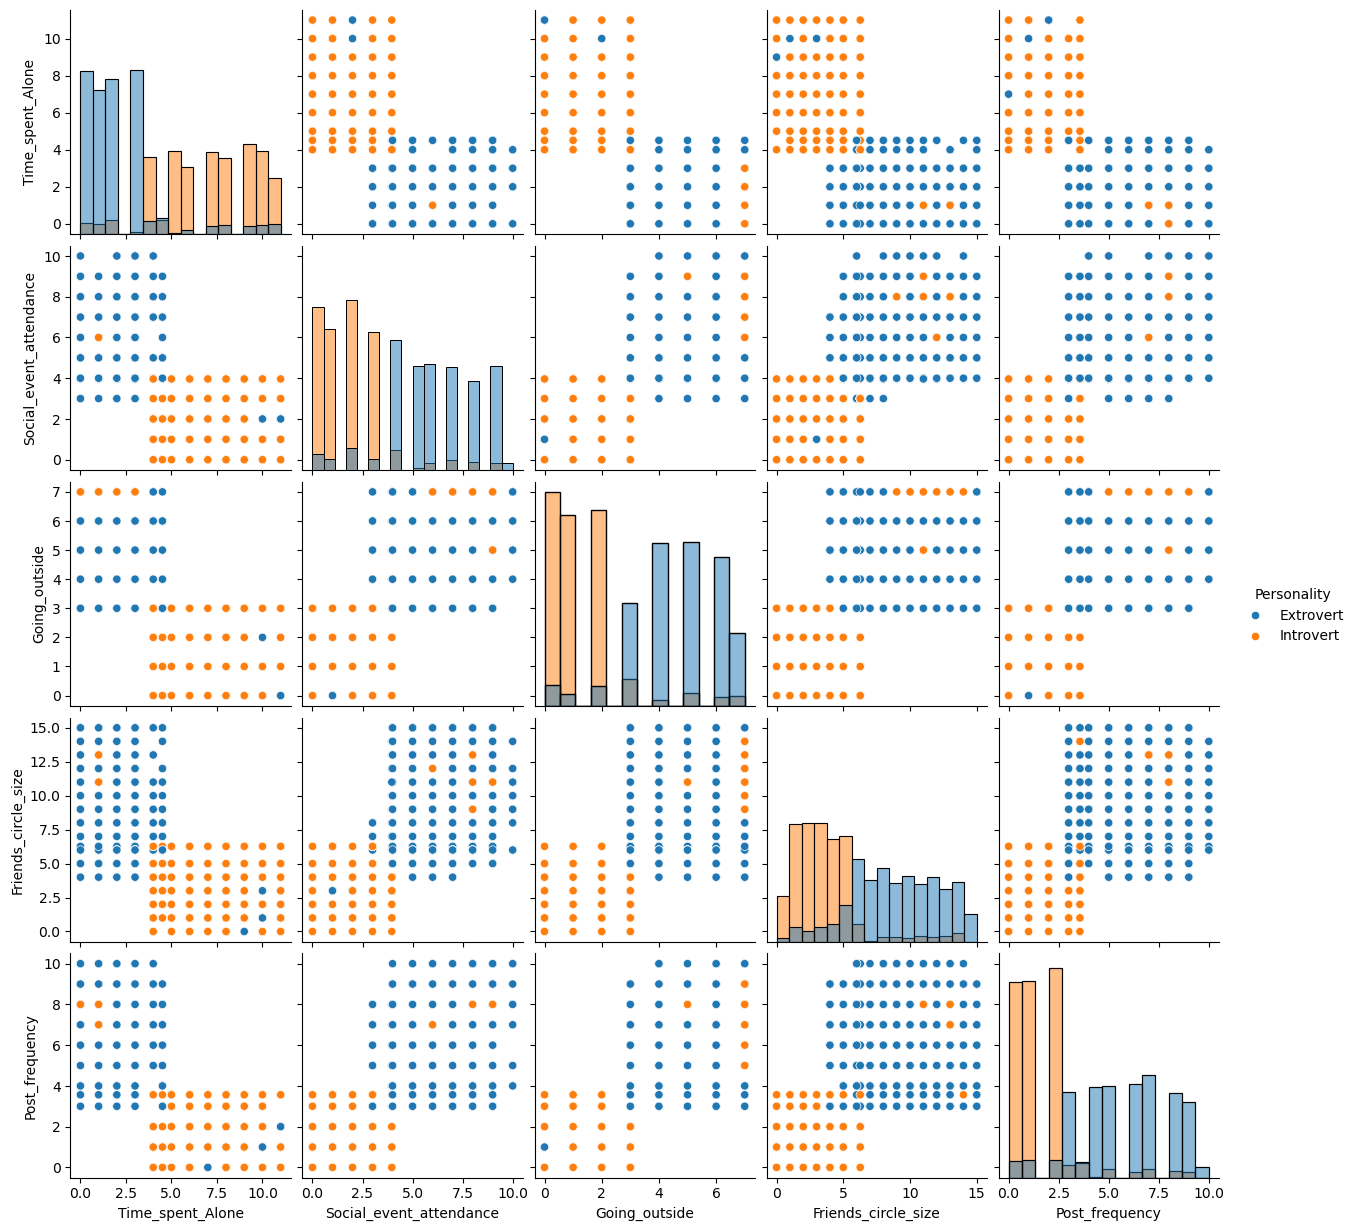

In [9]:
# Feature vs Target variable
# How numerical feature impacts the Target feature (Personality feature)
sns.pairplot(df, hue='Personality',diag_kind="hist") 
plt.show()

Stage_fear
No     0.513793
Yes    0.486207
Name: proportion, dtype: float64


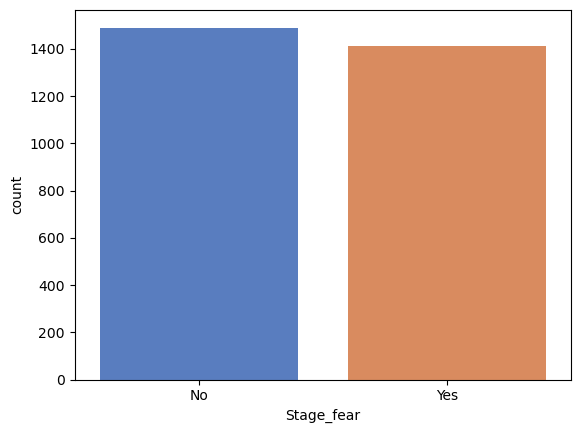

Drained_after_socializing
No     0.514828
Yes    0.485172
Name: proportion, dtype: float64


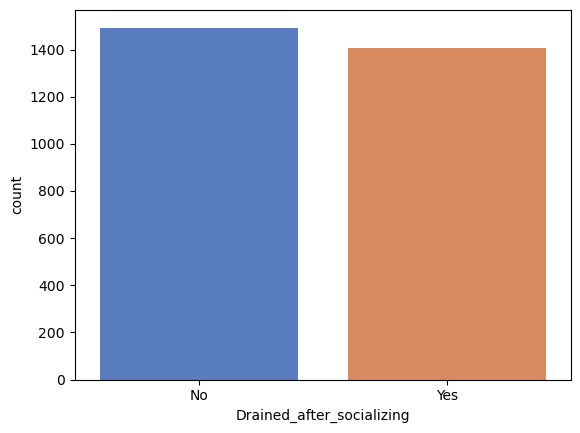

In [10]:
for col in categorical_cols:
    print(df[col].value_counts(normalize=True))
    sns.countplot(x=col, data=df, palette="muted")  # no need for hue=col
    plt.show()


Personality
Extrovert    0.514138
Introvert    0.485862
Name: proportion, dtype: float64


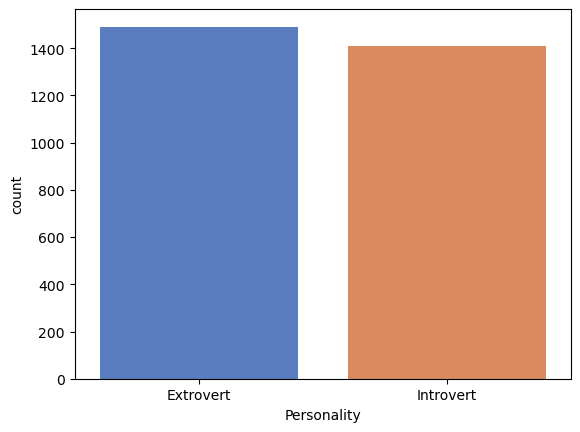

In [11]:
print(df[target_col].value_counts(normalize=True))
sns.countplot(x=target_col, data=df, palette='muted')
plt.show()

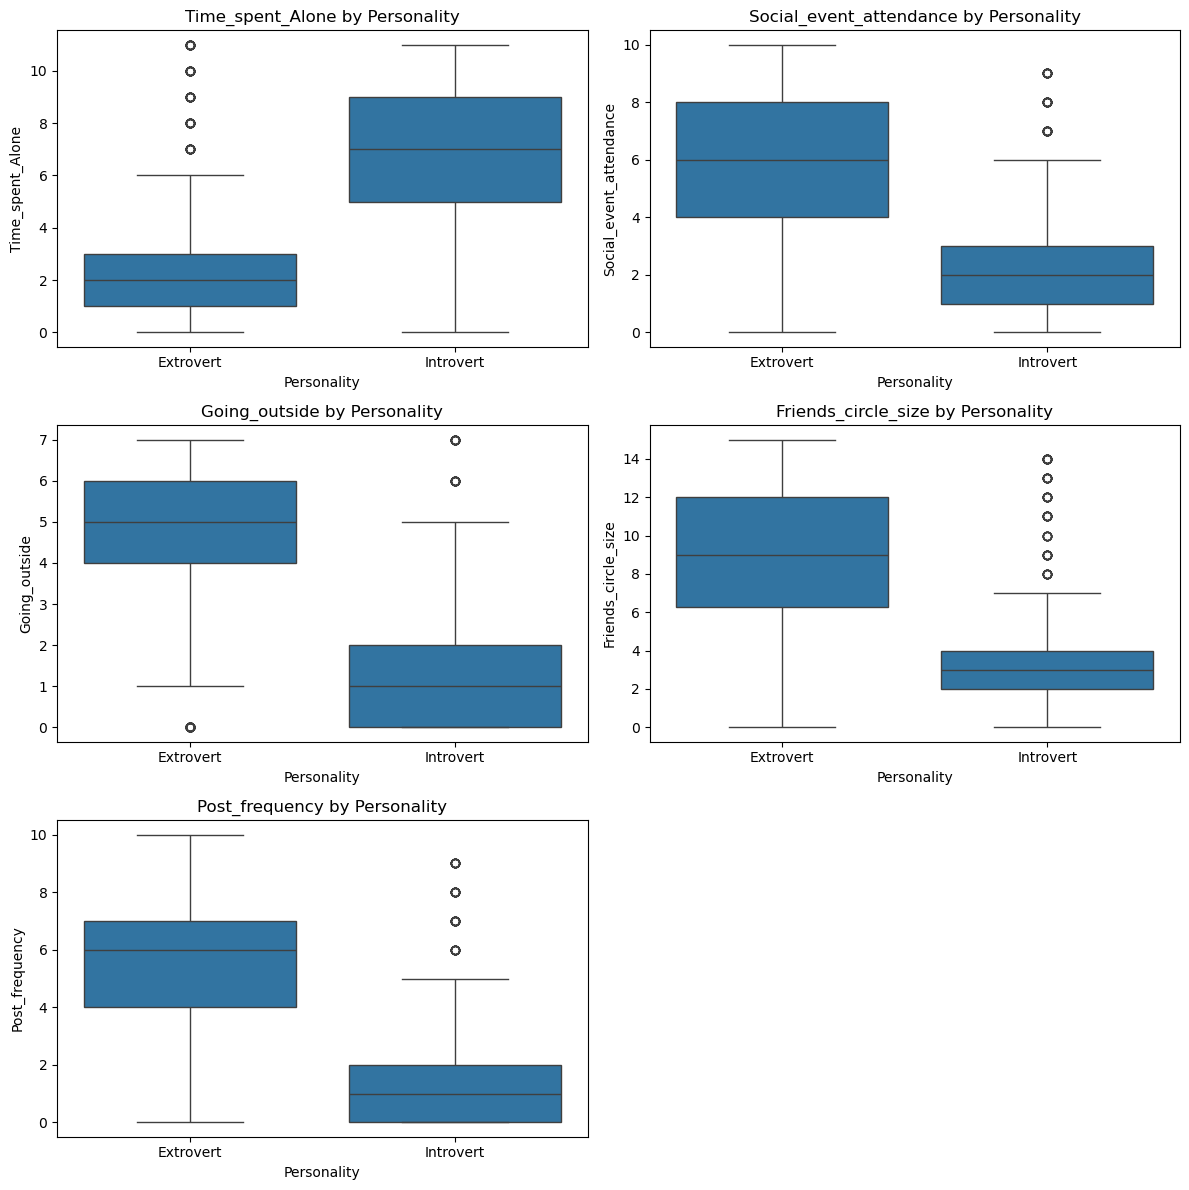

In [12]:
# Number of plots
n = len(numeric_cols)
rows = math.ceil(n / 2)   # 2 plots per row
cols = 2

plt.figure(figsize=(12, rows * 4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=target_col, y=col, data=df,)
    plt.title(f'{col} by {target_col}')

plt.tight_layout()
plt.show()

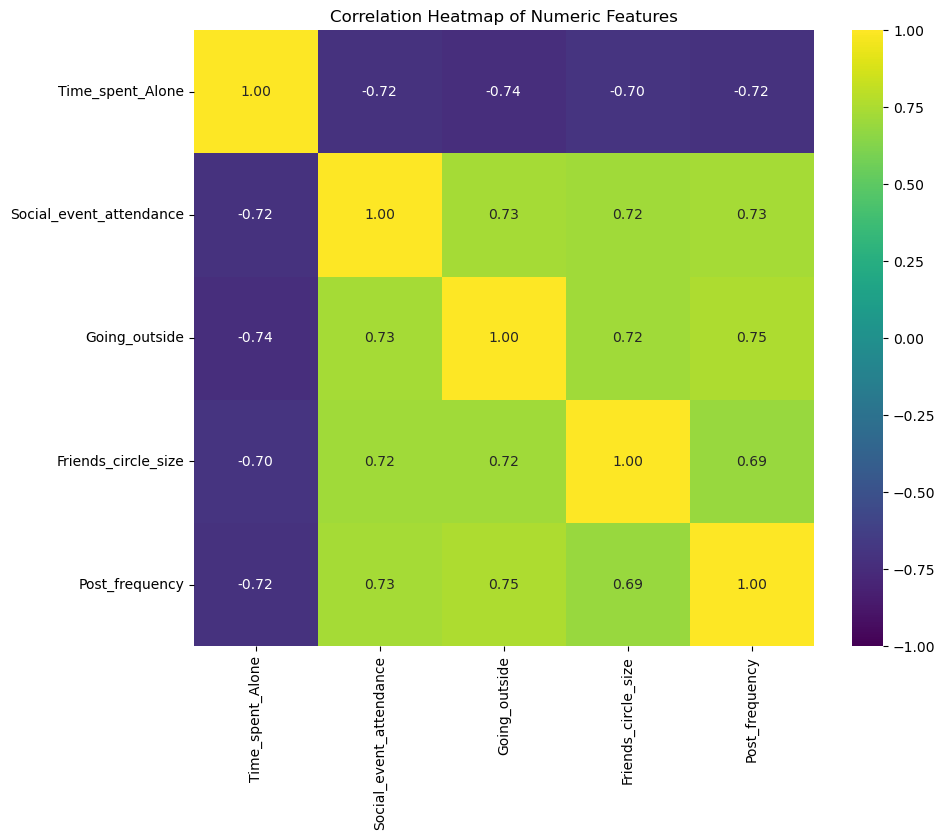

In [13]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='viridis', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [14]:
# Handling missing values
from sklearn.impute import SimpleImputer


# Numeric features: impute with median
numeric_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = numeric_imputer.fit_transform(df[numeric_cols])

# Categorical features: impute with mode
categorical_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

In [15]:
# Display distribution of categorical features
for col in categorical_cols:
    print(f"Distribution of {col}:")
    print(df[col].value_counts(normalize=True))
    print("-" * 50)

# Display distribution of numerical features
for col in numeric_cols:
    print(f"Distribution of {col}:")
    print(df[col].value_counts(normalize=True))
    print("-" * 50)

# Display distribution of target variable
print(f"Distribution of target column: {target_col}")
print(df[target_col].value_counts(normalize=True))
print("-" * 50)


Distribution of Stage_fear:
Stage_fear
No     0.513793
Yes    0.486207
Name: proportion, dtype: float64
--------------------------------------------------
Distribution of Drained_after_socializing:
Drained_after_socializing
No     0.514828
Yes    0.485172
Name: proportion, dtype: float64
--------------------------------------------------
Distribution of Time_spent_Alone:
Time_spent_Alone
0.000000     0.127241
2.000000     0.123103
3.000000     0.121724
1.000000     0.112414
9.000000     0.071034
10.000000    0.067586
4.000000     0.065517
7.000000     0.065517
5.000000     0.062069
8.000000     0.062069
6.000000     0.051724
11.000000    0.048276
4.505816     0.021724
Name: proportion, dtype: float64
--------------------------------------------------
Distribution of Social_event_attendance:
Social_event_attendance
2.000000     0.140690
0.000000     0.130345
1.000000     0.111034
3.000000     0.109310
4.000000     0.087931
6.000000     0.082414
7.000000     0.082414
9.000000     0.08137

In [16]:
# Data Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])
print(f"Encoded classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode categorical features
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Update feature list
encoded_columns = [col for col in df.columns if col != target_col]

Encoded classes: {'Extrovert': 0, 'Introvert': 1}


In [17]:
# Cap outliers instead of removing
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [18]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
# Handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# Interaction features
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)
X_train['Alone_to_Social_Ratio'] = X_train['Time_spent_Alone'] / (X_train['Social_event_attendance'] + 1)
X_test['Alone_to_Social_Ratio'] = X_test['Time_spent_Alone'] / (X_test['Social_event_attendance'] + 1)
X_train['Social_Comfort_Index'] = (X_train['Friends_circle_size'] + X_train['Post_frequency'] - X_train['Stage_fear_Yes']) / 3
X_test['Social_Comfort_Index'] = (X_test['Friends_circle_size'] + X_test['Post_frequency'] - X_test['Stage_fear_Yes']) / 3
X_train['Social_Overload'] = X_train['Drained_after_socializing_Yes'] * X_train['Social_event_attendance']
X_test['Social_Overload'] = X_test['Drained_after_socializing_Yes'] * X_test['Social_event_attendance']

# Binned features
X_train['Time_spent_Alone_Binned'] = pd.qcut(X_train['Time_spent_Alone'], q=3, labels=['Low', 'Medium', 'High'])
X_test['Time_spent_Alone_Binned'] = pd.qcut(X_test['Time_spent_Alone'], q=3, labels=['Low', 'Medium', 'High'])
X_train = pd.get_dummies(X_train, columns=['Time_spent_Alone_Binned'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Time_spent_Alone_Binned'], drop_first=True)

from sklearn.preprocessing import PolynomialFeatures

# Polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly_features_train = poly.fit_transform(X_train[['Time_spent_Alone', 'Social_event_attendance', 'Friends_circle_size']])
poly_features_test = poly.transform(X_test[['Time_spent_Alone', 'Social_event_attendance', 'Friends_circle_size']])
poly_feature_names = poly.get_feature_names_out(['Time_spent_Alone', 'Social_event_attendance', 'Friends_circle_size'])
X_train[poly_feature_names] = poly_features_train
X_test[poly_feature_names] = poly_features_test

# Update scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
logistic = LogisticRegression(max_iter = 1000) # max_iter deafalut=100

In [22]:
logistic.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [23]:
y_pred = logistic.predict(X_test_scaled)

In [24]:
print(y_pred)

[0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 1 1 1 0 0 1 1 1 1 0 0 0 0 0 1 1 0 0 0
 0 0 0 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 0 0 1 1 1 1 0 0 1 0 1
 1 1 0 0 1 1 0 0 1 0 1 1 0 0 1 1 0 1 0 0 0 1 0 1 1 0 1 0 1 1 1 0 1 1 0 1 1
 1 1 0 1 1 0 0 1 0 0 1 1 0 0 1 1 1 1 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 1 0 1 1
 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 1 0 0 1 0 1 1 0 0 0 0 1 0 0 1 1
 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 0 1 1 0 1 1 1 0 1 1 1 0 0 0 0 0 1 1 1
 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 0 0 0 1 1 1 0 1 0 0 0 1 1 0
 0 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0
 0 1 0 1 0 0 1 0 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 0 0 0 1 1 1 0 1 1 1 1
 0 1 1 1 0 1 0 1 0 0 0 0 0 0 0 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 0 0 1 0
 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 0 0 1 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 1 1
 1 0 0 0 0 0 0 0 1 1 1 0 1 0 1 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 1 0 1
 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 0 0 1 0 1 1 0 1 1 0 1 

In [25]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
score = accuracy_score(y_pred, y_test)
print(f"Accuracy Score:{score}")

Accuracy Score:0.906896551724138


In [26]:
print("Model Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Model Classification Report:
              precision    recall  f1-score   support

   Extrovert       0.92      0.90      0.91       298
   Introvert       0.89      0.92      0.91       282

    accuracy                           0.91       580
   macro avg       0.91      0.91      0.91       580
weighted avg       0.91      0.91      0.91       580



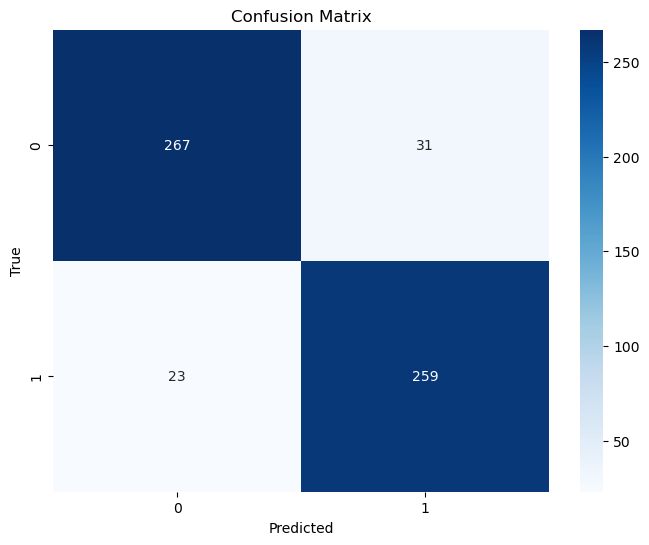

In [27]:
# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

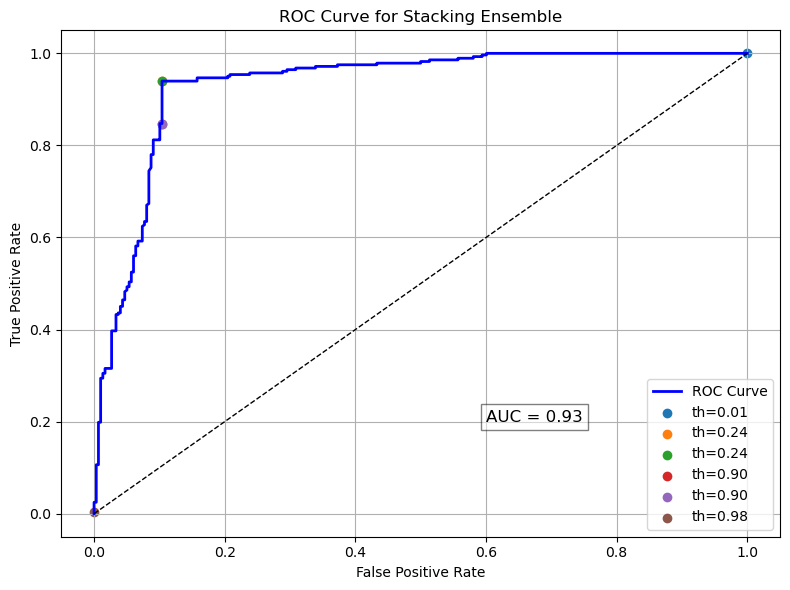

In [28]:
y_scores = logistic.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Annotate AUC
plt.text(0.6, 0.2, f'AUC = {roc_auc:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Optional: plot some threshold points
thresholds_to_plot = np.linspace(0, 1, 6)
for thresh in thresholds_to_plot:
    idx = np.argmin(np.abs(thresholds - thresh))
    plt.scatter(fpr[idx], tpr[idx], label=f"th={thresholds[idx]:.2f}")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Stacking Ensemble')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
model = LogisticRegression(max_iter=1000)

# Common hyperparameters
C_values = [0.1, 1, 10]

param_grid = [
    # Solvers that only support l2 (or None)
    {'solver': ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag'],
     'penalty': ['l2', None],
     'C': C_values},

    # liblinear supports l1 and l2
    {'solver': ['liblinear'],
     'penalty': ['l1', 'l2'],
     'C': C_values},

    # saga supports everything + l1_ratio
    {'solver': ['saga'],
     'penalty': ['l1', 'l2', 'elasticnet', None],
     'C': C_values,
     'l1_ratio': [0.1, 0.5, 0.9]},
]


In [30]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold()

In [31]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator = model, param_grid=param_grid, scoring = 'accuracy', n_jobs = -1, cv=cv)
grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid=[{'C': [0.1, 1, 10], 'penalty': ['l2', None],
                          'solver': ['lbfgs', 'newton-cg', 'newton-cholesky',
                                     'sag']},
                         {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2'],
                          'solver': ['liblinear']},
                         {'C': [0.1, 1, 10], 'l1_ratio': [0.1, 0.5, 0.9],
                          'penalty': ['l1', 'l2', 'elasticnet', None],
                          'solver': ['saga']}],
             scoring='accuracy')

In [32]:
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid=[{'C': [0.1, 1, 10], 'penalty': ['l2', None],
                          'solver': ['lbfgs', 'newton-cg', 'newton-cholesky',
                                     'sag']},
                         {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2'],
                          'solver': ['liblinear']},
                         {'C': [0.1, 1, 10], 'l1_ratio': [0.1, 0.5, 0.9],
                          'penalty': ['l1', 'l2', 'elasticnet', None],
                          'solver': ['saga']}],
             scoring='accuracy')

In [33]:
grid.best_params_

{'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}

In [34]:
grid.best_estimator_

LogisticRegression(C=0.1, max_iter=1000, solver='newton-cg')

In [35]:
grid.best_score_

0.9358753717007448

In [36]:
y_predx = grid.predict(X_test_scaled)

In [37]:
scorex = accuracy_score(y_predx, y_test)
print(f"Accuracy Score:{score}")

Accuracy Score:0.906896551724138


In [38]:
print("HyperParameter Model Classification Report:")
print(classification_report(y_test, y_predx, target_names=le.classes_))

HyperParameter Model Classification Report:
              precision    recall  f1-score   support

   Extrovert       0.93      0.90      0.91       298
   Introvert       0.89      0.93      0.91       282

    accuracy                           0.91       580
   macro avg       0.91      0.91      0.91       580
weighted avg       0.91      0.91      0.91       580



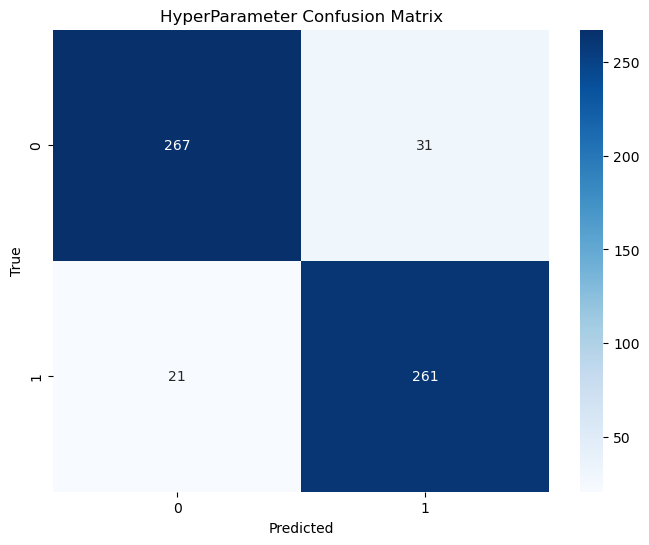

In [39]:
# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_predx), annot=True, fmt='d', cmap='Blues')
plt.title('HyperParameter Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

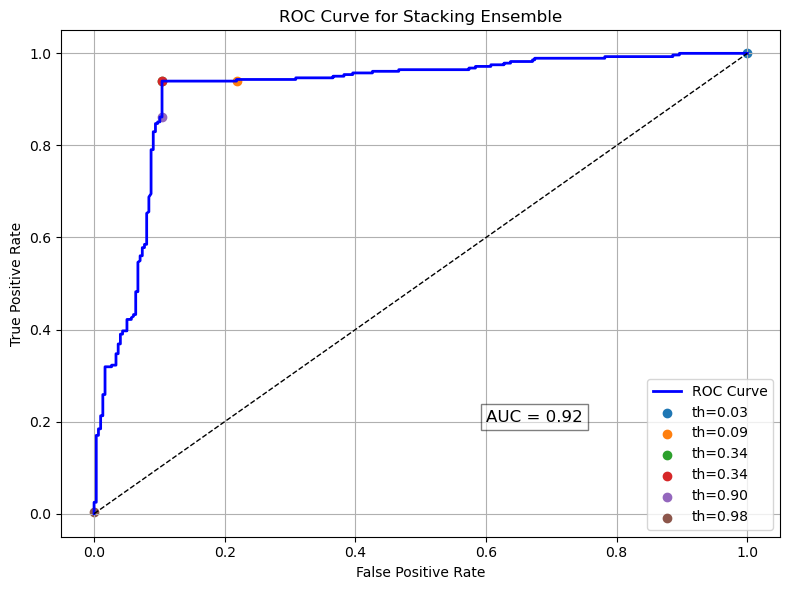

In [40]:
y_scores = grid.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Annotate AUC
plt.text(0.6, 0.2, f'AUC = {roc_auc:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Optional: plot some threshold points
thresholds_to_plot = np.linspace(0, 1, 6)
for thresh in thresholds_to_plot:
    idx = np.argmin(np.abs(thresholds - thresh))
    plt.scatter(fpr[idx], tpr[idx], label=f"th={thresholds[idx]:.2f}")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Stacking Ensemble')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
distances = np.sqrt((1 - tpr)**2 + fpr**2)
best_idx = np.argmin(distances)
best_threshold = thresholds[best_idx]
print(best_threshold)

0.3433005615157948


In [42]:
y_pred_class = (y_scores >= 0.33).astype(int)

In [43]:
print("Threshold Model Classification Report:")
print(classification_report(y_test, y_pred_class, target_names=le.classes_))

Threshold Model Classification Report:
              precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       298
   Introvert       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



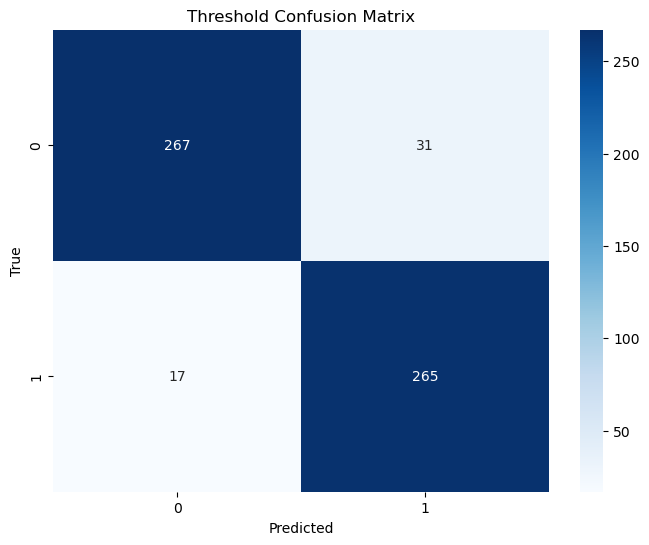

In [44]:
# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_class), annot=True, fmt='d', cmap='Blues')
plt.title('Threshold Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [45]:
import pickle
pickle_out = open('classifier.pkl','wb')
pickle.dump(grid,pickle_out)
pickle_out.close()